In [1]:
from transformers import AutoProcessor, AutoModelForImageTextToText

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = AutoModelForImageTextToText.from_pretrained("Salesforce/blip-image-captioning-base")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

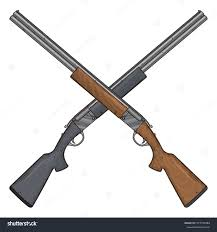

In [3]:
from PIL import Image
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# charge une image (exemple depuis ton dataset Kaggle)
img_path = "fusil.jpg"
image = Image.open(img_path).convert("RGB")
image

In [7]:
@torch.no_grad()
def generate_caption(image_path, max_new_tokens=40):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=5
    )
    return processor.decode(output_ids[0], skip_special_tokens=True)
image
response = generate_caption(img_path)
print(response)

a rifle and a rifle on a white background


In [ ]:
from abc import ABC
from openai import OpenAI


class BaseLLMClient(ABC):
    """Base LLM client. Call the LLM to generate a response based on the provided context.
    The server is ollama in this case with models like llama3.1, phi3, etc.
    The context is a rewritten captioning generated by a vision model.
    """
    
    def __init__(self, model: str, temperature: float = 0.1):
        self._model = model
        self._temperature = temperature
        self._client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
    def generate_response(self, context: str, language: str = "fr") -> str:
        """Generate a response based on the provided context."""
        prompt = f"""Context: Rewrite the following caption: {context}\n in the following language: {language}"""

        return prompt
    def call_llm(self, prompt: str) -> str:
        """Call LLM API (to be implemented by subclasses)."""
        try:
            response = self._client.chat.completions.create(
                model=self._model,
                messages=[{"role": "user", "content": prompt}],
                temperature=self._temperature
            )
            print(response.choices[0].message.content)
            return response.choices[0].message.content
        except Exception as e:
            print(f"LLM API call failed: {e}")
            return ""
llm_client = BaseLLMClient(model="llama3.1", temperature=0.7)
prompt = llm_client.generate_response(context=response, language="français")
llm_response = llm_client.call_llm(prompt)
print(llm_response)

LLM API call failed: Connection error.

